In [17]:

import pandas as pd
from datetime import datetime, timedelta
from difflib import SequenceMatcher
import matplotlib.pyplot as plt
import sys, pathlib, os
import pickle
from pathlib import Path
import seaborn as sns
import numpy as np
from lifelines.utils import to_long_format
from lifelines.utils import add_covariate_to_timeline
from lifelines import CoxTimeVaryingFitter
from statsmodels.distributions.empirical_distribution import ECDF
from scipy.stats import ks_2samp
from scipy import stats
from matplotlib.ticker import MultipleLocator
import matplotlib.ticker as mtick
import warnings

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

PROJECTS_DIR = pathlib.Path(os.getcwd()).resolve().parents[1]   # .../Proyectos

#  Añadimos a sys.path sólo si no está
if str(PROJECTS_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECTS_DIR))
    
from Efectividad_Nirse.Code.preproces_prod3 import *

def son_similares(cadena1, cadena2):
    return SequenceMatcher(None, cadena1, cadena2).ratio()

path_actual = Path.cwd()
path_data = path_actual.parent / 'Data'
path_eff_data = path_actual.parent.parent / 'Efectividad_Nirse' / 'Data'

new = pd.read_csv(path_data / '2025-04-22_Egresos2024.csv',encoding= 'latin1', sep = '|')#pd.read_csv(path_data / '2024-12-16_Egresos.csv',encoding= 'latin1', sep = '|')
new_2025 = pd.read_csv(path_data / '2025-12-04_Egresos2025.csv',encoding= 'latin1', sep = '|') # 2025-08-18_Egresos2025 este archivo anda bien 
egresos_1 = pd.read_csv(path_data / "egresos.csv",encoding = "latin1",sep="|")

egresos = pd.concat([egresos_1,new,new_2025])
runes_raros = ['db97ccd245df4a064b20e703623e43804e14dce53f3bb5befb947e0803dd6fd0','ad9e5f32c7e34b52e22b5778b45bd95476c79bed20c550712e75fb43e409085c'] # SON 2 WEONES HIGH RISK DE LA ALEMNA SANTIAGO CON COMUNA INCORRECTA
egresos.loc[egresos.RUT.isin(runes_raros),'COMUNA'] = 13114.0

# file = path_data / "tributacion_egresos hospitalarios_2025.xlsx"

# trib_publi = pd.read_excel(
#     file,
#     sheet_name="EstadoCargaIEEH_SS",  
#     skiprows=0
# )

# trib_priv = pd.read_excel(
#     file,
#     sheet_name="EstadoCargaIEEH_SEREMI",
#     skiprows=0
# )

# trib = pd.concat([trib_publi,trib_priv])

trib_publi = pd.read_excel(
    path_data / "EstadoCargaIEEH_SS.xlsx",
    sheet_name="EstadoCargaIEEH_SS",  
    skiprows=0
)

trib_priv = pd.read_excel(
    path_data / "EstadoCargaIEEH_SEREMI.xlsx",
    sheet_name="EstadoCargaIEEH_SEREMI",
    skiprows=0
)

trib = pd.concat([trib_publi,trib_priv])  

comunas = (
    pd.read_excel(path_data/"comunas.xlsx")
    .drop_duplicates()
    .rename(columns = {'C_COM': 'COMUNA','NOM_REG':'NOMBRE_REGION'})
)

In [25]:
diagnosticos_upc = [406, 412, 415, 405, 411, 414, 310, 311, 312, 320, 323, 324]
areasMB = [401, 402, 403, 404, 407, 408, 409, 410, 413]

In [26]:
trib['CodigoEstablecimiento'] = trib['Codigo Establecimiento']

acusados = trib[trib['May'].isna()].CodigoEstablecimiento.dropna().astype(int)
cols_diagnostico = ['AREA_FUNC_I',
                    'AREAF_1_TRAS', 
                    'AREAF_2_TRAS', 
                    'AREAF_3_TRAS', 
                    'AREAF_4_TRAS', 
                    'AREAF_5_TRAS', 
                    'AREAF_6_TRAS', 
                    'AREAF_7_TRAS', 
                    'AREAF_8_TRAS', 
                    'AREAF_9_TRAS']

tras_date = {'AREA_FUNC_I': 'fechaIng',
             'AREAF_1_TRAS':'fecha_tras_1',
             'AREAF_2_TRAS':'fecha_tras_2',
             'AREAF_3_TRAS':'fecha_tras_3',
             'AREAF_4_TRAS':'fecha_tras_4',
             'AREAF_5_TRAS':'fecha_tras_5',
             'AREAF_6_TRAS':'fecha_tras_6', 
             'AREAF_7_TRAS':'fecha_tras_7', 
             'AREAF_8_TRAS':'fecha_tras_8', 
             'AREAF_9_TRAS':'fecha_tras_9'}

def obtener_fecha_primer_upc(row):
    for col in cols_diagnostico:
        if row[col] == 1:
            fecha_col = tras_date[col]
            return row[fecha_col]
    return None

egresos_plus = (egresos
                .rename(columns={'RUT':'RUN'})
                .merge(comunas,how='left',on ='COMUNA')
                .assign(FECHA_NAC     = lambda x: pd.to_datetime({'year': x['A_NAC'], 'month': x['M_NAC'], 'day': x['D_NAC']}, format='%Y-%m-%d'),
                        fechaIng      = lambda x: pd.to_datetime({'year': x['ANO_ING'], 'month': x['MES_ING'], 'day': x['DIA_ING']}, format='%Y-%m-%d'),
                        fechaEgr      = lambda x: pd.to_datetime({'year': x['ANO_EGR'], 'month': x['MES_EGR'], 'day': x['DIA_EGR']}, format='%Y-%m-%d'),
                        NOMBRE_REGION = lambda x: x['NOMBRE_REGION'].str.replace('Región', '').str.strip().fillna('Ignorada'),
                        age_years     = lambda x: ((x['fechaIng'] - x['FECHA_NAC']).dt.days / 365),
                        age_months    = lambda x: ((x['fechaIng'] - x['FECHA_NAC']).dt.days / 28 ),
                        # FECHA_NAC=lambda x: pd.to_datetime(x["FECHA_NAC"], format="%Y-%m-%d"),
                        # fechaIng=lambda x: pd.to_datetime(x["fechaIng"], format="%Y-%m-%d")
                        ))
subset_columnas = ['RUN', 'FECHA_NAC','fechaIng','SEXO','NOMBRE_REGION','AREA_FUNC_I', 'ANO_ING','DIAG1','ESTAB', 'DIAS_ESTAD', 'fechaEgr', 'PREVI','age_years', 'age_months',
                   'DIA_1_TRAS', 'MES_1_TRAS', 'ANO_1_TRAS', 'AREAF_1_TRAS','DIA_2_TRAS', 'MES_2_TRAS', 'ANO_2_TRAS', 'AREAF_2_TRAS', 'DIA_3_TRAS',
                   'MES_3_TRAS', 'ANO_3_TRAS', 'AREAF_3_TRAS', 'DIA_4_TRAS', 'MES_4_TRAS','ANO_4_TRAS', 'AREAF_4_TRAS', 'DIA_5_TRAS', 'MES_5_TRAS', 
                   'ANO_5_TRAS','AREAF_5_TRAS', 'DIA_6_TRAS', 'MES_6_TRAS', 'ANO_6_TRAS', 'AREAF_6_TRAS', 'DIA_7_TRAS', 'MES_7_TRAS', 'ANO_7_TRAS',
                   'AREAF_7_TRAS', 'DIA_8_TRAS', 'MES_8_TRAS', 'ANO_8_TRAS','AREAF_8_TRAS', 'DIA_9_TRAS', 'MES_9_TRAS', 'ANO_9_TRAS', 'AREAF_9_TRAS']

df_filtrado = egresos_plus[subset_columnas]

In [37]:
subset_columnas = ['RUN', 'FECHA_NAC','fechaIng','SEXO','NOMBRE_REGION','AREA_FUNC_I', 'ANO_ING','DIAG1','ESTAB', 'DIAS_ESTAD', 'fechaEgr','COND_EGR', 'PREVI','age_years', 'age_months',
                   'DIA_1_TRAS', 'MES_1_TRAS', 'ANO_1_TRAS', 'AREAF_1_TRAS','DIA_2_TRAS', 'MES_2_TRAS', 'ANO_2_TRAS', 'AREAF_2_TRAS', 'DIA_3_TRAS',
                   'MES_3_TRAS', 'ANO_3_TRAS', 'AREAF_3_TRAS', 'DIA_4_TRAS', 'MES_4_TRAS','ANO_4_TRAS', 'AREAF_4_TRAS', 'DIA_5_TRAS', 'MES_5_TRAS', 
                   'ANO_5_TRAS','AREAF_5_TRAS', 'DIA_6_TRAS', 'MES_6_TRAS', 'ANO_6_TRAS', 'AREAF_6_TRAS', 'DIA_7_TRAS', 'MES_7_TRAS', 'ANO_7_TRAS',
                   'AREAF_7_TRAS', 'DIA_8_TRAS', 'MES_8_TRAS', 'ANO_8_TRAS','AREAF_8_TRAS', 'DIA_9_TRAS', 'MES_9_TRAS', 'ANO_9_TRAS', 'AREAF_9_TRAS']

df_filtrado = egresos_plus[subset_columnas]

In [ ]:
lista_cods_rotaviturs = [
    # --- Específico de rotavirus ---
    'A080', #"Enteritis por rotavirus (código específico para rotavirus confirmado)", 
    
     # --- Códigos virales cercanos cuando NO se especifica agente ---
    'A083', #"Otras enteritis virales (viral no especificado, puede usarse antes de conocer el agente)",
    'A084', #"Gastroenteropatía y colitis viral (diagnóstico viral sin agente identificado)",
    'A085', #"Diarrea del viajero (ocasionalmente se usa como diarrea viral inespecífica)",
 
    # --- Gastroenteritis inespecífica (muy frecuente en bases reales) ---
    # 'A090', #"Infección intestinal de etiología bacteriana presunta (a veces codifica GE hasta confirmar agente)",
    # 'A099', #"Gastroenteritis y colitis no especificada (uno de los códigos más comunes antes de identificar rotavirus)",
 
    # # --- Síntomas que pueden registrarse si no se codifica diagnóstico etiológico ---
    # 'R11', # "Náuseas y vómitos (síntomas frecuentes en rotavirus)",
    # 'R197', #"Diarrea (síntoma principal cuando no se ingresa código etiológico)",
    
    #  # --- Complicaciones típicas asociadas a cuadros moderados/graves ---
    # 'E860', #"Deshidratación (muy común en cuadros de gastroenteritis por rotavirus)",
    # 'E869', #"Depleción de volumen / trastornos del equilibrio de líquidos (asociados a vómitos y diarrea por rotavirus)",
 
    #  # --- Condición neonatal que puede coexistir (NO causada por rotavirus) ---
    # 'P77',  #"Enterocolitis necrotizante del recién nacido (no causada por rotavirus, pero puede coexistir en contexto neonatal)"
    ] 

In [4]:
rotavirus_1 = ['A080', 'A083', 'A084', 'A085','A090','A099']
rotavirus_2 = ['A080', 'A083', 'A084', 'A085']
rotavirus_3 = ['A080']

In [ ]:
df_filtrado_rota_1 = (
    df_filtrado[df_filtrado[['DIAG1']].isin(rotavirus_1).any(axis=1)]
    # df_filtrado[df_filtrado[['DIAG1','DIAG3','DIAG4','DIAG5','DIAG6','DIAG7','DIAG8','DIAG9','DIAG10','DIAG11']].isin(cods_vrs).any(axis=1)]
)

df_filtrado_rota_2 = (
    df_filtrado[df_filtrado[['DIAG1']].isin(rotavirus_2).any(axis=1)]
    # df_filtrado[df_filtrado[['DIAG1','DIAG3','DIAG4','DIAG5','DIAG6','DIAG7','DIAG8','DIAG9','DIAG10','DIAG11']].isin(cods_vrs).any(axis=1)]
)

df_filtrado_rota_3 = (
    df_filtrado[df_filtrado[['DIAG1']].isin(rotavirus_3).any(axis=1)]
    # df_filtrado[df_filtrado[['DIAG1','DIAG3','DIAG4','DIAG5','DIAG6','DIAG7','DIAG8','DIAG9','DIAG10','DIAG11']].isin(cods_vrs).any(axis=1)]
)

In [35]:
def curvas_por_ano_semana(df, acumulado=False, age=None):
    """
    df: DataFrame con columnas 'fechaIng' (datetime), 'RUN', 'DIAG1', 'age_years' (float).
    acumulado: si True, grafica casos acumulados por semana.
    age: string con rango 'a-b' en años (ej: '0-1', '1-4'). Si None, usa todas las edades.
    """
    print(df.DIAG1.unique())
    anios_interes = [2019, 2022, 2023, 2024, 2025]

    # --- Filtro por edad (si corresponde) ---
    df_age = df.copy()

    if age is not None:
        try:
            low_str, high_str = age.split('-')
            low = float(low_str.strip())
            high = float(high_str.strip())
        except Exception:
            raise ValueError("El parámetro 'age' debe tener formato 'a-b', por ejemplo '0-1' o '1-4'.")

        # Aseguramos tipo numérico de age_years por si acaso
        df_age = df_age.assign(age_years=lambda d: pd.to_numeric(d['age_years'], errors='coerce'))
        # Filtro: [low, high)
        df_age = df_age.query("age_years >= @low and age_years < @high")

    # --- Construcción de la tabla año-semana ---
    tabla = (
        df_age
        .assign(
            year=lambda d: d['fechaIng'].dt.isocalendar().year.astype(int),
            week=lambda d: d['fechaIng'].dt.isocalendar().week.astype(int),
        )
        .query("year in @anios_interes")
        .groupby(['year', 'week'], as_index=False)
        .agg(n_casos=('RUN', 'nunique'))
        .pivot(index='week', columns='year', values='n_casos')
        .reindex(range(1, 53))
        .fillna(0)
    )

    # --- Acumulado si se pide ---
    if acumulado:
        tabla = tabla.cumsum()

    # --- Texto extra para títulos / labels según edad ---
    if age is None:
        age_text = ""
    else:
        age_text = f" (edad {age} años)"

    # --- Gráfico ---
    plt.figure(figsize=(10, 6))

    for year in anios_interes:
        if year in tabla.columns:
            plt.plot(
                tabla.index,
                tabla[year],
                marker='o',
                label=f"{year}" + (" (acum.)" if acumulado else "")
            )

    plt.xlabel('Semana del año')
    plt.ylabel('Número de casos (RUN únicos)' + (" acumulados" if acumulado else ""))
    plt.title('Casos por rotavirus por semana y año' + age_text + (" (acumulado)" if acumulado else ""))
    plt.xticks(range(1, 53, 2))
    plt.grid(alpha=0.3)
    plt.legend(title='Año')
    plt.tight_layout()
    plt.show()

curvas_por_ano_semana(df_filtrado_rota_1,acumulado=True,age='0-1')
curvas_por_ano_semana(df_filtrado_rota_2,acumulado=True,age='0-1')
curvas_por_ano_semana(df_filtrado_rota_3,acumulado=True,age='0-1')



NameError: name 'df_filtrado_rota_1' is not defined

In [43]:
df_filtrado_vrs_deadths.query('age_years<1').groupby('ANO_ING').RUN.nunique()

ANO_ING
2019    3
2021    1
2022    6
2023    6
2024    1
2025    1
Name: RUN, dtype: int64

In [45]:
df_filtrado_vrs_deadths.query('age_years<1').query('ANO_ING==2025')

,RUN,FECHA_NAC,fechaIng,SEXO,NOMBRE_REGION,AREA_FUNC_I,ANO_ING,DIAG1,ESTAB,DIAS_ESTAD,fechaEgr,COND_EGR,PREVI,age_years,age_months,DIA_1_TRAS,MES_1_TRAS,ANO_1_TRAS,AREAF_1_TRAS,DIA_2_TRAS,MES_2_TRAS,ANO_2_TRAS,AREAF_2_TRAS,DIA_3_TRAS,MES_3_TRAS,ANO_3_TRAS,AREAF_3_TRAS,DIA_4_TRAS,MES_4_TRAS,ANO_4_TRAS,AREAF_4_TRAS,DIA_5_TRAS,MES_5_TRAS,ANO_5_TRAS,AREAF_5_TRAS,DIA_6_TRAS,MES_6_TRAS,ANO_6_TRAS,AREAF_6_TRAS,DIA_7_TRAS,MES_7_TRAS,ANO_7_TRAS,AREAF_7_TRAS,DIA_8_TRAS,MES_8_TRAS,ANO_8_TRAS,AREAF_8_TRAS,DIA_9_TRAS,MES_9_TRAS,ANO_9_TRAS,AREAF_9_TRAS
10482476,e98e691a5cba267ad0d9c7556e79ff2a666432fb57bd404af8093379058bae46,2024-04-24,2025-01-10,1.0,De Coquimbo,412.0,2025,J121,105100,208.0,2025-08-06,2,1.0,0.715068,9.321429,17.0,3.0,2025.0,410.0,16.0,4.0,2025.0,412.0,17.0,4.0,2025.0,410.0,3.0,6.0,2025.0,412.0,10.0,6.0,2025.0,410.0,9.0,7.0,2025.0,412.0,25.0,7.0,2025.0,410.0,4.0,8.0,2025.0,412.0,NaN,NaN,NaN,NaN


['J210' 'J121' 'J219' 'J205']


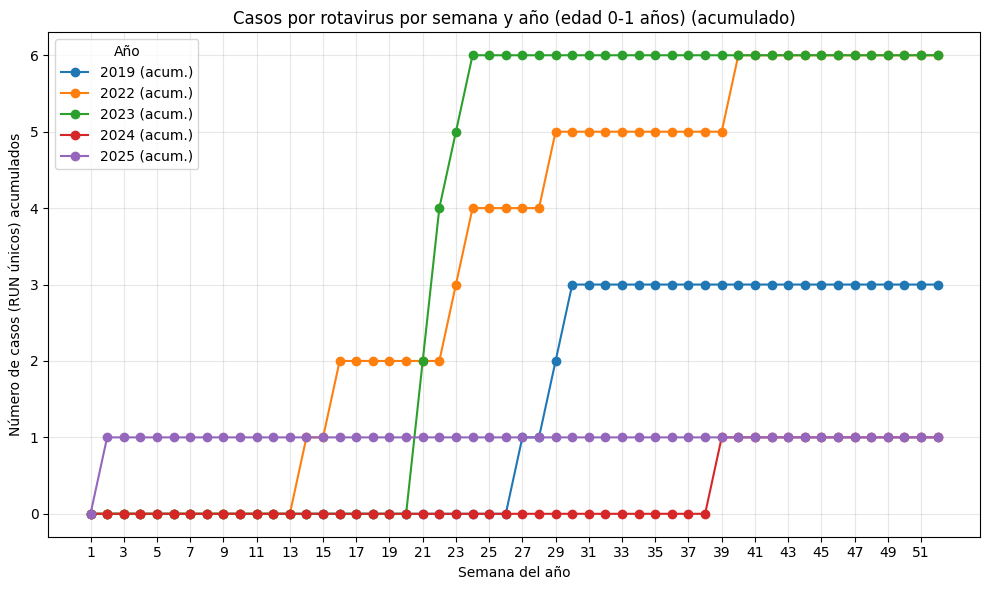

In [41]:
df_filtrado_vrs_deadths = (
    df_filtrado[df_filtrado[['DIAG1']].isin(['J121', 'J205', 'J210','J219', 'B974' ]).any(axis=1)]
    # df_filtrado[df_filtrado[['DIAG1','DIAG3','DIAG4','DIAG5','DIAG6','DIAG7','DIAG8','DIAG9','DIAG10','DIAG11']].isin(cods_vrs).any(axis=1)]
    .query('COND_EGR==2')
)

curvas_por_ano_semana(df_filtrado_vrs_deadths,acumulado=True,age='0-1')

In [16]:
df_filtrado_rota_2.query('age_years<=1').assign(year=lambda d: d['fechaIng'].dt.isocalendar().year.astype(int)).groupby('year',as_index=False).RUN.nunique()

,year,RUN
0,2018,5
1,2019,913
2,2020,264
3,2021,172
4,2022,321
5,2023,696
6,2024,982
7,2025,566


# CALCULAR LO DE ABAJO PARA MB Y ICU (AÑADIR ESO AL CODIGO PARA QU ELA BASE GUARDE CAMA CRÍTICA)

In [17]:
df_filtrado_rota_2.query('age_years<=1').assign(year=lambda d: d['fechaIng'].dt.isocalendar().year.astype(int)).groupby('year',as_index=False).DIAS_ESTAD.mean()

,year,DIAS_ESTAD
0,2018,17.800000
1,2019,3.689103
2,2020,3.759398
3,2021,3.595376
4,2022,3.259259
5,2023,3.957064
6,2024,3.475932
7,2025,3.907534


In [52]:
influenza_1  = [
    "J09X", "J100", "J101", "J108"
]

influenza_2 = [
    "J09X", "J100", "J101", "J108", 
    "J110", "J111", "J118"
]

influenza_3 = [
    # Influenza confirmada
    "J09X", "J100", "J101", "J108",
    # Influenza clínica sin virus identificado
    "J110", "J111", "J118",
    # Neumonías virales plausibles como influenza mal codificada
    "J128", "J129", "J171"
]

In [53]:
df_filtrado_influenza_1 = (
    df_filtrado[df_filtrado[['DIAG1']].isin(influenza_1).any(axis=1)]
    # df_filtrado[df_filtrado[['DIAG1','DIAG3','DIAG4','DIAG5','DIAG6','DIAG7','DIAG8','DIAG9','DIAG10','DIAG11']].isin(cods_vrs).any(axis=1)]
)

df_filtrado_influenza_2 = (
    df_filtrado[df_filtrado[['DIAG1']].isin(influenza_2).any(axis=1)]
    # df_filtrado[df_filtrado[['DIAG1','DIAG3','DIAG4','DIAG5','DIAG6','DIAG7','DIAG8','DIAG9','DIAG10','DIAG11']].isin(cods_vrs).any(axis=1)]
)

df_filtrado_influenza_3 = (
    df_filtrado[df_filtrado[['DIAG1']].isin(influenza_3).any(axis=1)]
    # df_filtrado[df_filtrado[['DIAG1','DIAG3','DIAG4','DIAG5','DIAG6','DIAG7','DIAG8','DIAG9','DIAG10','DIAG11']].isin(cods_vrs).any(axis=1)]
)

['J101' 'J100' 'J108' 'J09X']


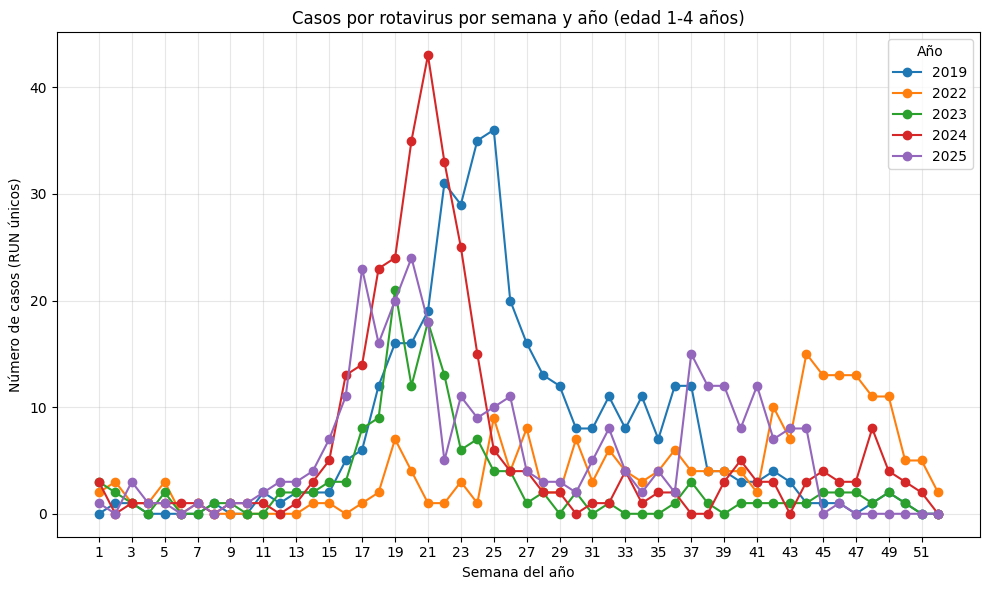

['J101' 'J111' 'J110' 'J100' 'J118' 'J108' 'J09X']


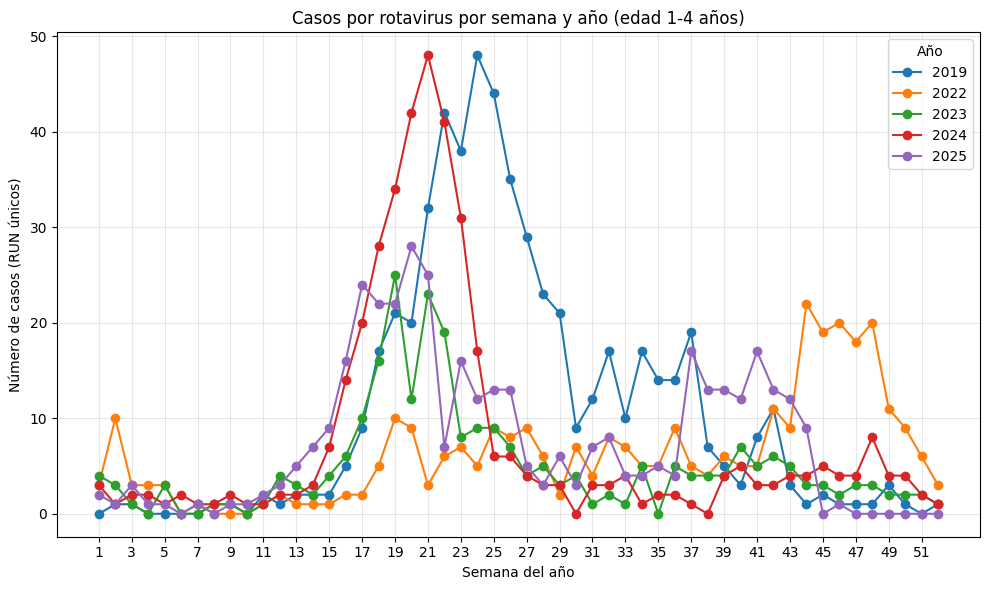

['J129' 'J101' 'J111' 'J110' 'J128' 'J100' 'J118' 'J108' 'J09X' 'J171']


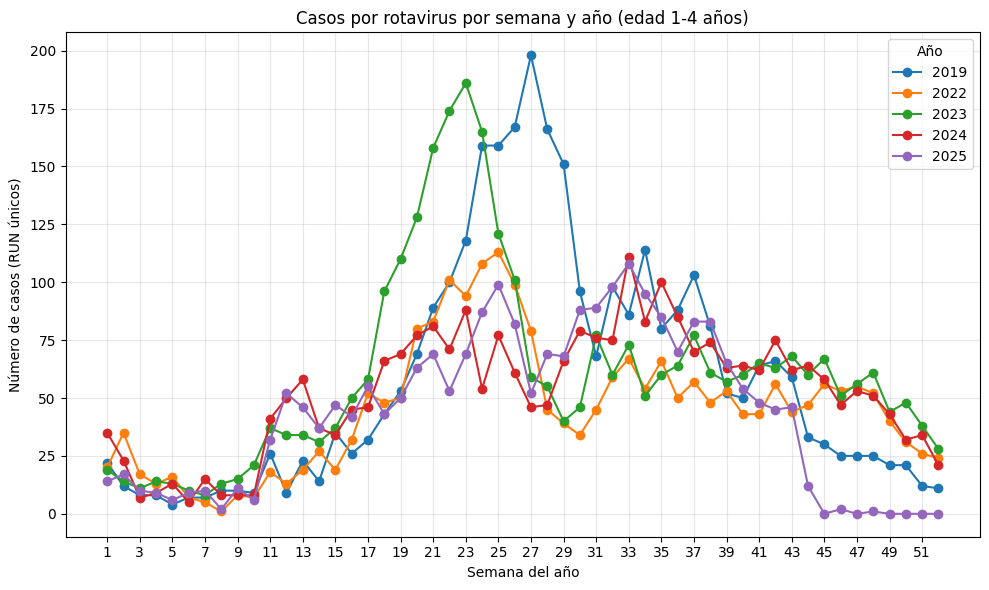

In [55]:
curvas_por_ano_semana(df_filtrado_influenza_1,acumulado=False,age='1-4')
curvas_por_ano_semana(df_filtrado_influenza_2,acumulado=False,age='1-4')
curvas_por_ano_semana(df_filtrado_influenza_3,acumulado=False,age='1-4')

In [74]:
df_epi_influenza = pd.read_excel(path_data/'influenza_cases_by_week.xlsx')
df_epi_influenza_total = (df_epi_influenza
                          .groupby(['Año','SE'],as_index=False)
                          .agg({'Muestras positivas':'sum'})
                          .rename(columns={'Año':'year','SE':'week','Muestras positivas':'muestras_positivas'})
                          )

In [ ]:
pull_codigos_influenza_neumonia = [
    "J09X",  # Influenza aviar / Influenza A (H1N1)
    "J100",  # Influenza con neumonía, virus identificado
    "J101",  # Influenza con otras manifestaciones respiratorias, virus identificado
    "J108",  # Influenza con otras manifestaciones, virus identificado
    "J110",  # Influenza con neumonía, virus no identificado
    "J111",  # Influenza con otras manifestaciones respiratorias, virus no identificado
    "J118",  # Influenza con otras manifestaciones, virus no identificado

    "J120",  # Neumonía debida a adenovirus
    "J121",  # Neumonía debida a virus sincicial respiratorio (RSV)
    "J122",  # Neumonía debida a virus parainfluenza
    "J123",  # Neumonía debida a metapneumovirus humano (hMPV)
    "J128",  # Neumonía debida a otros virus
    "J129",  # Neumonía viral, no especificada

    "J13X",  # Neumonía por Streptococcus pneumoniae
    "J14X",  # Neumonía por Haemophilus influenzae
    "J150",  # Neumonía por Klebsiella pneumoniae
    "J151",  # Neumonía por Pseudomonas
    "J152",  # Neumonía por estafilococos
    "J153",  # Neumonía por estreptococos grupo B
    "J154",  # Neumonía por otros estreptococos
    "J155",  # Neumonía por Escherichia coli
    "J156",  # Neumonía por otras bacterias aerobias gramnegativas
    "J157",  # Neumonía por Mycoplasma pneumoniae
    "J158",  # Otras neumonías bacterianas
    "J159",  # Neumonía bacteriana, no especificada

    "J160",  # Neumonía por clamidias
    "J168",  # Neumonía por otros microorganismos infecciosos especificados

    "J170",  # Neumonía en enfermedades bacterianas clasificadas en otra parte
    "J171",  # Neumonía en enfermedades virales clasificadas en otra parte
    "J172",  # Neumonía en micosis
    "J173",  # Neumonía en enfermedades parasitarias
    "J178",  # Neumonía en otras enfermedades clasificadas en otra parte

    "J180",  # Bronconeumonía, no especificada
    "J181",  # Neumonía lobar, no especificada
    "J182",  # Neumonía hipostática, no especificada
    "J188",  # Otras neumonías, microorganismo no especificado
    "J189",  # Neumonía, no especificada
]


# 1) Tabla wide de egresos por código/semana
df_wide = (
    df_filtrado[df_filtrado[['DIAG1']].isin(pull_codigos_influenza_neumonia).any(axis=1)]
    .assign(
        week=lambda d: d['fechaIng'].dt.isocalendar().week,
        year=lambda d: d['fechaIng'].dt.isocalendar().year,
    )
    .pivot_table(
        index=["year", "week"],
        columns="DIAG1",
        values="RUN",
        aggfunc="size",
        fill_value=0
    )
)

# 2) Denominador por semana: todos los egresos del pull
df_wide = df_wide.assign(den=lambda d: d.sum(axis=1))

# Si en alguna semana no hay egresos del pull, la sacamos
df_wide = df_wide.query("den > 0")



In [ ]:
# Solo columnas de códigos (sin la columna 'den')
codigos = df_wide.columns.drop('den')

# Matriz de proporciones por código
df_prop = df_wide[codigos].div(df_wide['den'], axis=0)

df_vig_ratio = (
    df_epi_influenza_total
    .rename(columns={'año': 'year'})
    [['year', 'week', 'ratio_positividad']]
)

# Índice igual que df_prop
df_prop_indexed = df_prop.reset_index()   # trae year, week

df_all = (
    df_prop_indexed
    .merge(df_vig_ratio, on=['year', 'week'], how='inner')
    .sort_values(['year','week'])
    .reset_index(drop=True)
)

# Actualizamos codigos por si el merge filtró semanas
codigos = [c for c in codigos if c in df_all.columns]

# Matriz Q (proporciones por código) y vector P_vig (ratio vigilancia)
Q = df_all[codigos].to_numpy()                        # shape (T, C)
P_vig = df_all['ratio_positividad'].to_numpy()        # shape (T,)
T, C = Q.shape

print("Q shape:", Q.shape)
print("P_vig shape:", P_vig.shape)


In [ ]:
import gurobipy as gp
from gurobipy import GRB

m = gp.Model()

# Variables binarias: si el código c entra al subset
z = m.addVars(C, vtype=GRB.BINARY, name="z")

# Residuo por semana
r = m.addVars(T, vtype=GRB.CONTINUOUS, name="r")

# r_t = sum_c Q[t,c] z_c - P_vig[t]
for t in range(T):
    m.addConstr(
        r[t] == gp.quicksum(Q[t, c] * z[c] for c in range(C)) - P_vig[t]
    )

# Objetivo: minimizar suma de cuadrados de los residuos
# MIQP: objective = sum_t r_t^2
m.setObjective(gp.quicksum(r[t] * r[t] for t in range(T)), GRB.MINIMIZE)

m.optimize()

# ---------------------------
# Recuperar el mejor subset
# ---------------------------

codigos_seleccionados = [codigos[i] for i in range(C) if z[i].X > 0.5]

print("\nCódigos seleccionados:")
for c in codigos_seleccionados:
    print(" -", c)

['J459' 'J46X' 'J458' 'J450' 'J451' 'R062']


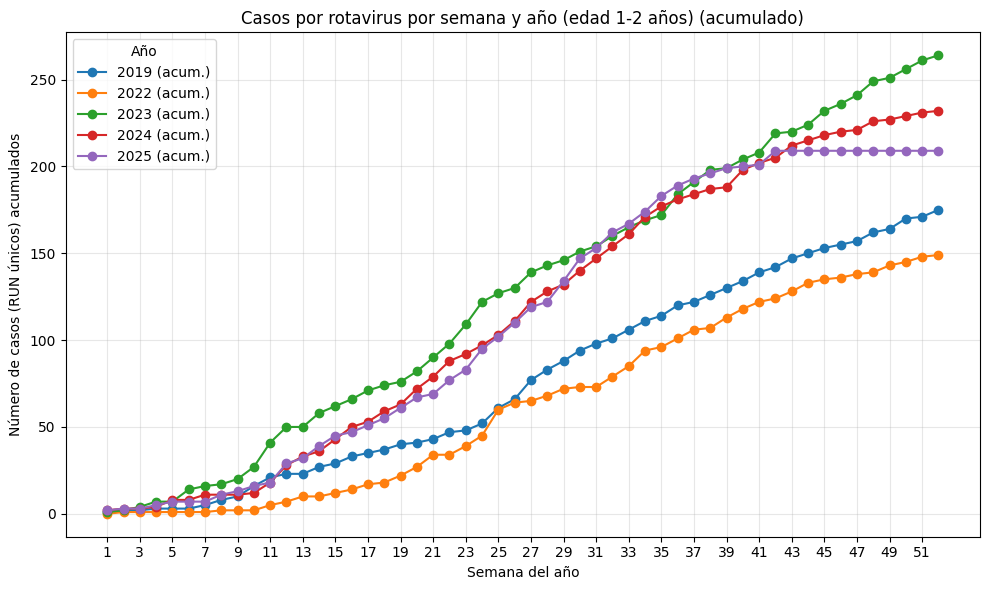

In [12]:
asma_1 = ['J450','J451','J458','J459','J46X','R062']
df_filtrado_asma = (
    df_filtrado[df_filtrado[['DIAG1']].isin(asma_1).any(axis=1)]
    # df_filtrado[df_filtrado[['DIAG1','DIAG3','DIAG4','DIAG5','DIAG6','DIAG7','DIAG8','DIAG9','DIAG10','DIAG11']].isin(cods_vrs).any(axis=1)]
)

curvas_por_ano_semana(df_filtrado_asma,acumulado=True,age='1-2')